In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [2]:
cd /content/drive/MyDrive/Savio

/content/drive/MyDrive/Savio


In [3]:
'''
Value Count Label_multi
0     1672837
4      231073
9      158930
2      128027
3       10293
6        5796
5        5499
1        1966
8          36
7          11
10          1

'''

df = pd.read_csv('engineered_features.csv')
top_3_labels = df['Label_multi'].value_counts().nlargest(3)
top_3_label_values = df['Label_multi'].value_counts().nlargest(3).index
df = df[df['Label_multi'].isin(top_3_label_values)]
label_mapping = {0: 0, 4: 1, 9: 2}
df['Label_multi'] = df['Label_multi'].map(label_mapping)

In [4]:
df['Label_multi'].value_counts()
df = df.drop(columns=['flow_duration_bin','packet_count_bin'])

In [5]:
df = df.fillna(0)

In [6]:
df.head()

,packet_count_ratio,byte_volume_ratio,byte_volume_diff,forward_dominant,backward_dominant,balanced_traffic,bytes_per_second,packets_per_second,iat_forward_backward_ratio,total_iat_variation,fwd_iat_variation,bwd_iat_variation,is_bursty,burstiness_score,iat_consistency,fwd_bwd_iat_similarity,syn_only,syn_ack,fin_only,rst_present,flag_density,syn_ack_ratio,fin_ack_ratio,urgent_flag_present,push_flag_present,urgent_push_combo,is_short_flow,is_medium_flow,is_long_flow,low_packet_count,medium_packet_count,high_packet_count,incomplete_session,abnormal_termination,normal_termination,zero_window_forward,zero_window_backward,zero_window_any,large_window_forward,large_window_backward,large_window_any,negative_window,header_length_ratio,total_header_length,header_length_diff,header_length_match,header_length_discrepancy,has_bulk_transfer,bulk_transfer_size,bulk_transfer_rate,bulk_direction_ratio,bulk_packet_ratio,segment_size_ratio,segment_size_diff,total_segment_size,calculated_avg_packet_size,avg_packet_size_diff,subflow_packet_ratio,subflow_byte_ratio,subflow_fwd_packet_ratio,subflow_bwd_packet_ratio,data_packet_ratio,has_data_packets,min_segment_size_anomaly,segment_size_consistency,activity_ratio,activity_variation,idle_variation,high_activity,low_activity,long_idle,short_idle,activity_range,idle_range,activity_idle_ratio,active_idle_correlation,fwd_bwd_packet_rate_ratio,fwd_bwd_byte_rate_ratio,high_flow_rate,low_flow_rate,high_byte_rate,low_byte_rate,packet_rate_consistency,byte_rate_consistency,timing_anomaly_score,traffic_pattern_risk,ddos_indicator,data_exfiltration_indicator,size_rate_interaction,duration_packet_interaction,duration_byte_interaction,syn_packet_ratio,ack_packet_ratio,fin_packet_ratio,iat_size_ratio,duration_size_ratio,subflow_main_packet_ratio,subflow_main_byte_ratio,log_flow_duration,log_total_fwd_packets,log_total_bwd_packets,log_total_fwd_bytes,log_total_bwd_bytes,log_flow_bytes_s,log_flow_packets_s,sqrt_flow_duration,sqrt_total_packets,reciprocal_flow_duration,reciprocal_packet_count,zscore_Flow_Duration,zscore_Total_Fwd_Packets,zscore_Total_Length_of_Fwd_Packets,zscore_Flow_Bytes_s,zscore_Flow_Packets_s,flow_duration_bin_numeric,packet_count_bin_numeric,Label_multi
0,2.0,12.000000,12.0,0,0,1,3.000000,0.500000,3.0,0.0,0.0,0.0,0,-0.750000,0.0,1.2,0,0,0,0,0.333333,0.0,0.0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,40.000000,40.0,40.0,1,0.0,0,0.0,0.0,0.0,0.0,6.000000,6.0,6.0,4.0,5.0,2.0,12.000000,0.666667,0.0,0.333333,1,0,2.857143,0.0,0.0,0.0,0,0,0,1,0.0,0.0,0.0,0,666666.666700,2.500000,0,0,1,0,0.999999,9.999998e-07,0.0,0.2,0,0,4.000000e+06,6.0,36.0,0.0,0.333333,0.0,0.428571,0.230769,0.666667,0.923077,1.386294,1.098612,0.000000,2.564949,0.00000,15.201805,13.410047,2.000000,1.732051,0.250000,0.333333,-0.457416,-0.009374,-0.050059,0.0,0.0,1.0,1.0,0
1,0.5,0.857143,0.0,0,0,1,0.109091,0.018182,0.0,0.0,0.0,0.0,0,-0.990909,0.0,0.0,0,0,0,0,0.666667,0.0,0.0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0.952381,40.0,0.0,1,0.0,0,0.0,0.0,0.0,0.0,0.857143,0.0,12.0,4.0,5.0,0.5,0.857143,0.500000,0.5,0.000000,0,0,2.857143,0.0,0.0,0.0,0,0,0,1,0.0,0.0,0.0,0,0.999891,0.513393,0,0,0,0,0.499973,4.999955e-07,0.0,0.0,0,0,5.504587e+04,109.0,1308.0,0.0,0.500000,0.0,0.000000,8.384615,0.666667,0.923077,4.700480,0.693147,0.693147,1.945910,1.94591,11.609078,9.817364,10.488088,1.732051,0.009091,0.333333,-0.457413,-0.010833,-0.050615,0.0,0.0,2.0,1.0,0
2,0.5,0.857143,0.0,0,0,1,0.226415,0.037736,0.0,0.0,0.0,0.0,0,-0.981132,0.0,0.0,0,0,0,0,0.666667,0.0,0.0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0.952381,40.0,0.0,1,0.0,0,0.0,0.0,0.0,0.0,0.857143,0.0,12.0,4.0,5.0,0.5,0.857143,0.500000,0.5,0.000000,0,0,2.857143,0.0,0.0,0.0,0,0,0,1,0.0,0.0,0.0,0,0.999948,0.527273,0,0,0,0,0.499987,4.999978e-07,0.0,0.0,0,0,1.153846e+05,52.0,624.0,0.0,0.500000,0.0,0.000000,4.000000,0.666667,0.923077,3.970292,0.693147,0.693147,1.945910,1.94591,12.349178,10.557440,7.280110,1.732051,0.018868,0.333333,-0.457415,-0.010833,-0.050615,0.0,0.0,1.0,1.0,0
3,0.5,0.857143,0.0,0,0,1,0.342857,0.

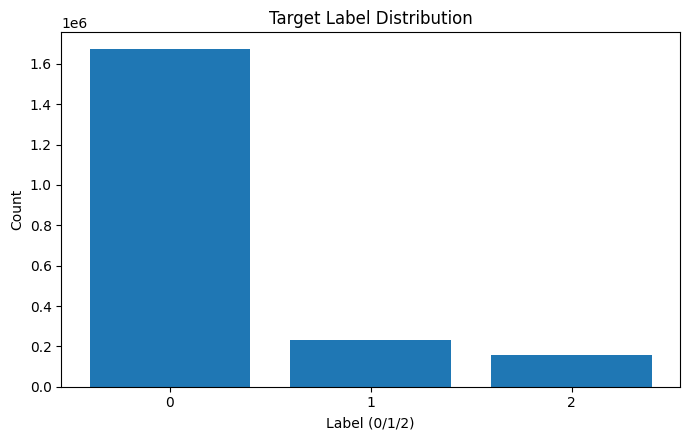

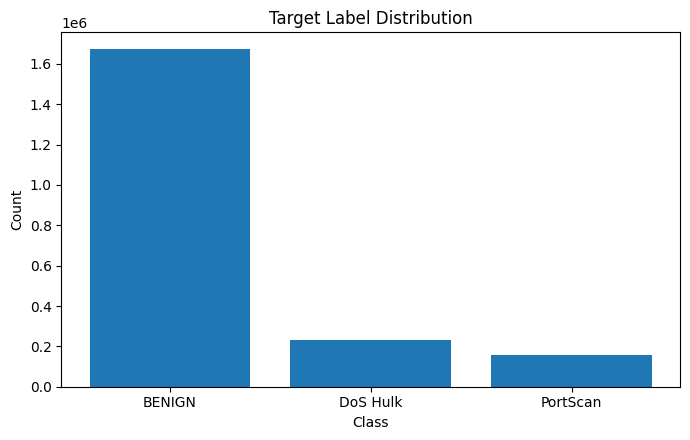

In [8]:
import matplotlib.pyplot as plt

label_col = "Label_multi"
y = df[label_col].astype(int)

counts = y.value_counts().sort_index()

plt.figure(figsize=(7,4.5))
plt.bar(counts.index.astype(str), counts.values)
plt.title("Target Label Distribution")
plt.xlabel("Label (0/1/2)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


name_map = {0:"BENIGN", 1:"DoS Hulk", 2:"PortScan"}  # edit if needed
x = [name_map.get(i, str(i)) for i in counts.index]

plt.figure(figsize=(7,4.5))
plt.bar(x, counts.values)
plt.title("Target Label Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


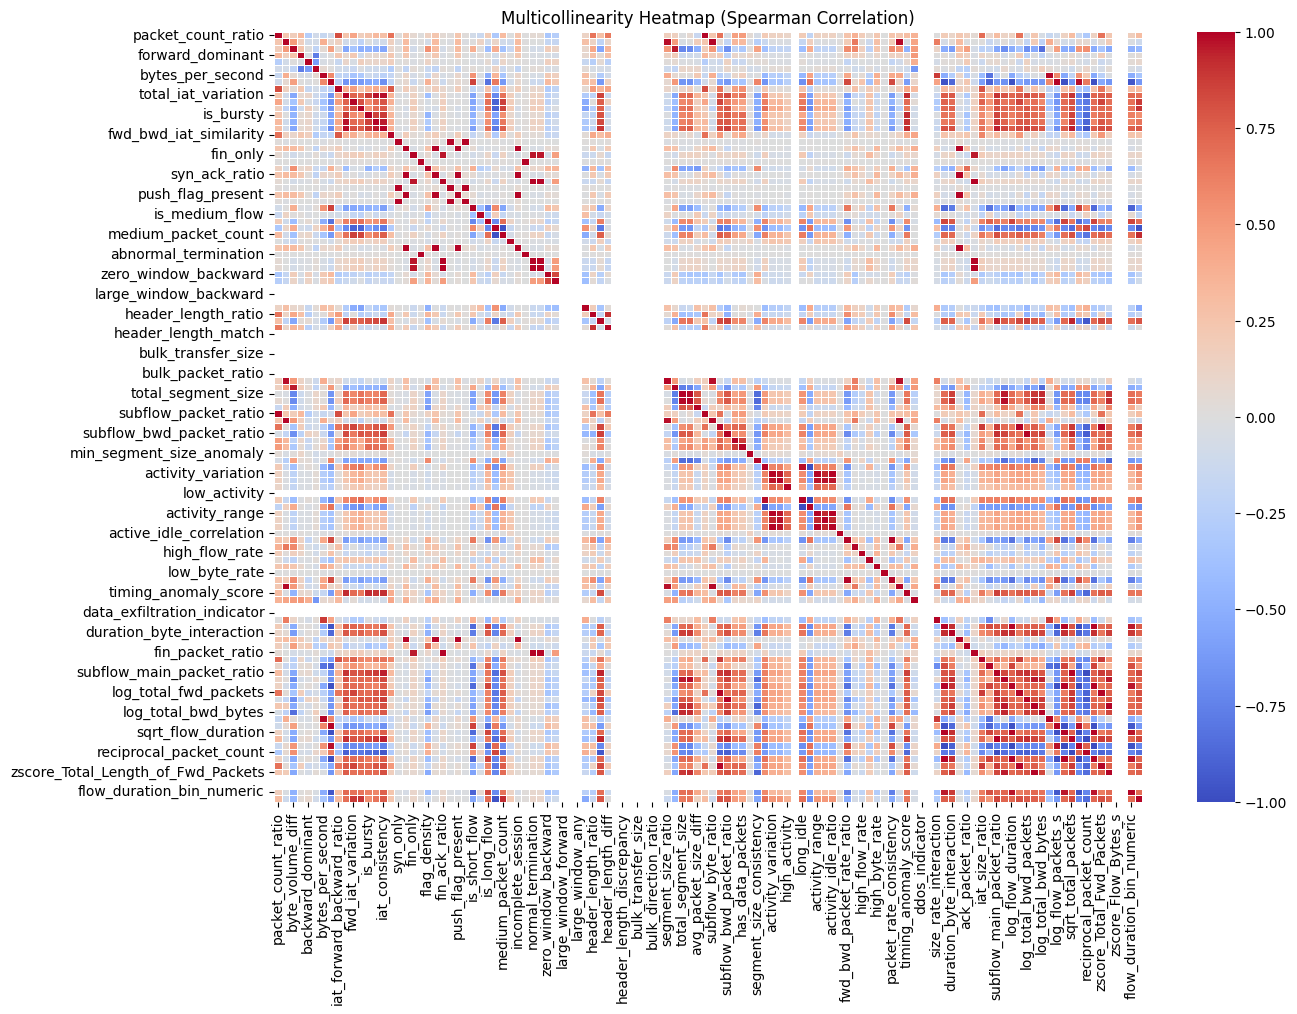

In [9]:
X = df.select_dtypes(include=[np.number]).drop(columns=[label_col], errors='ignore')
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

corr_matrix = X.corr(method='spearman')

# Plot heatmap (optional top 25 to make it readable)
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Multicollinearity Heatmap (Spearman Correlation)")
plt.show()


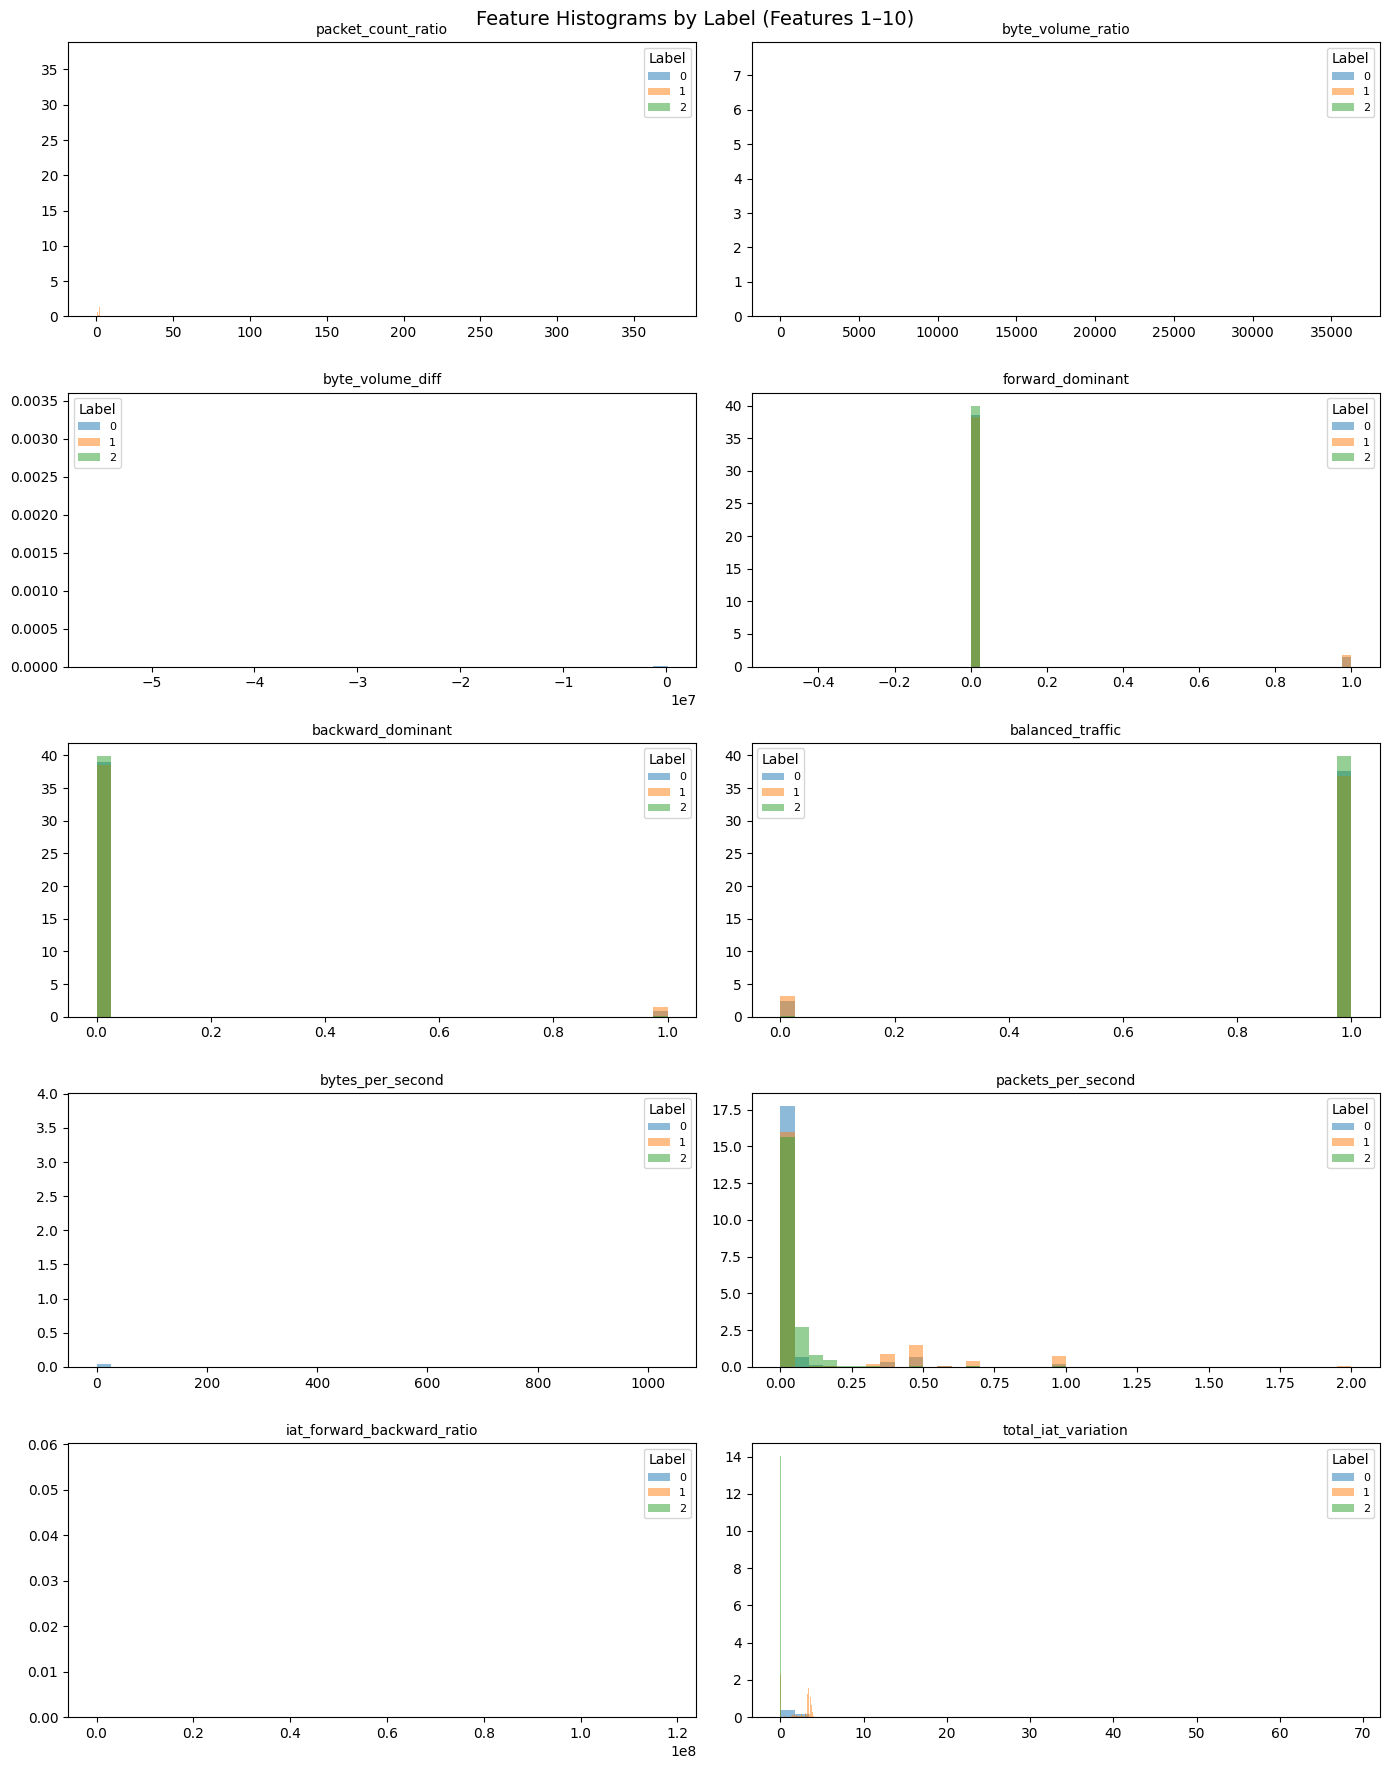

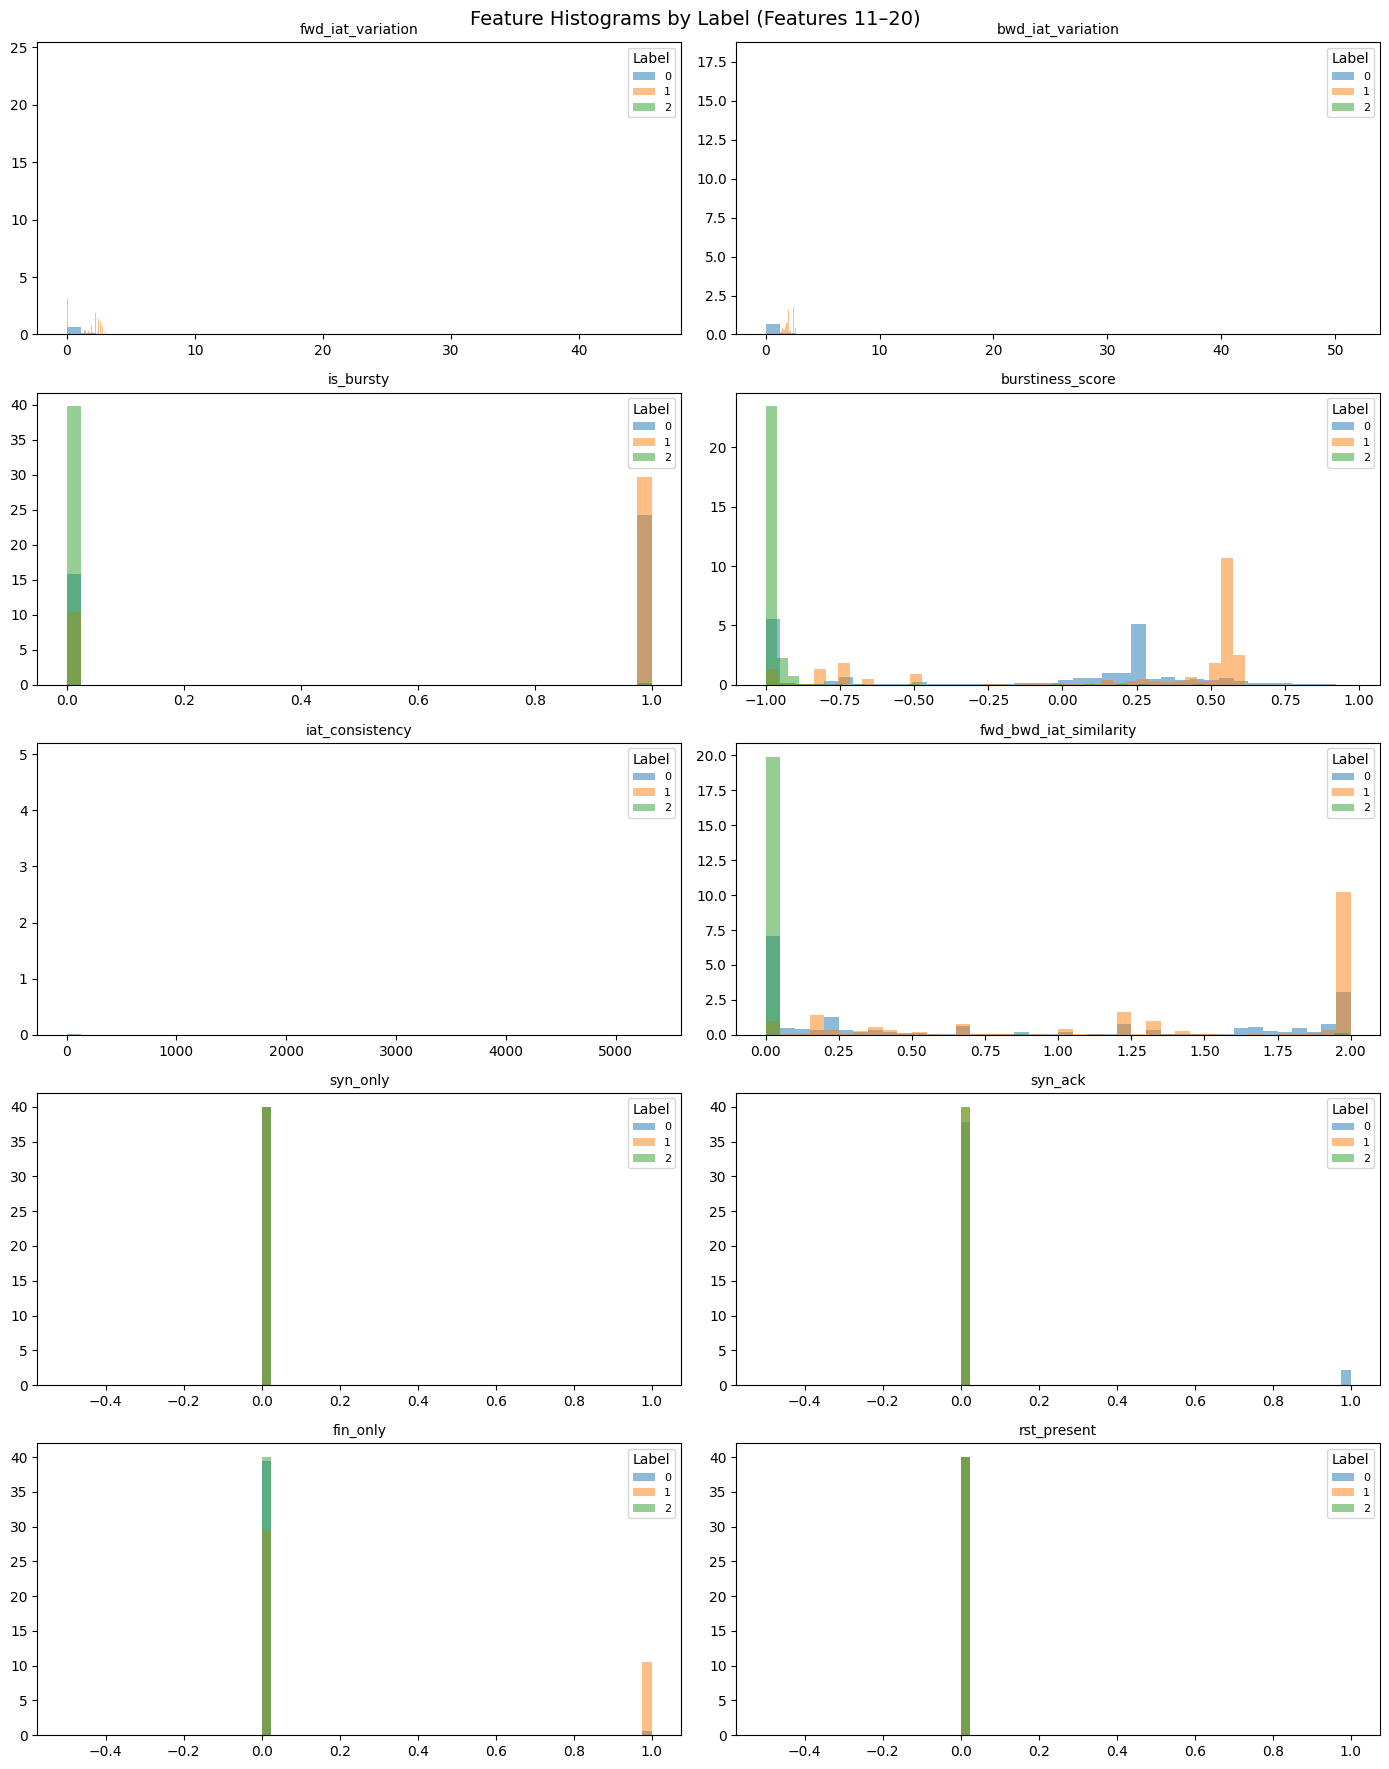

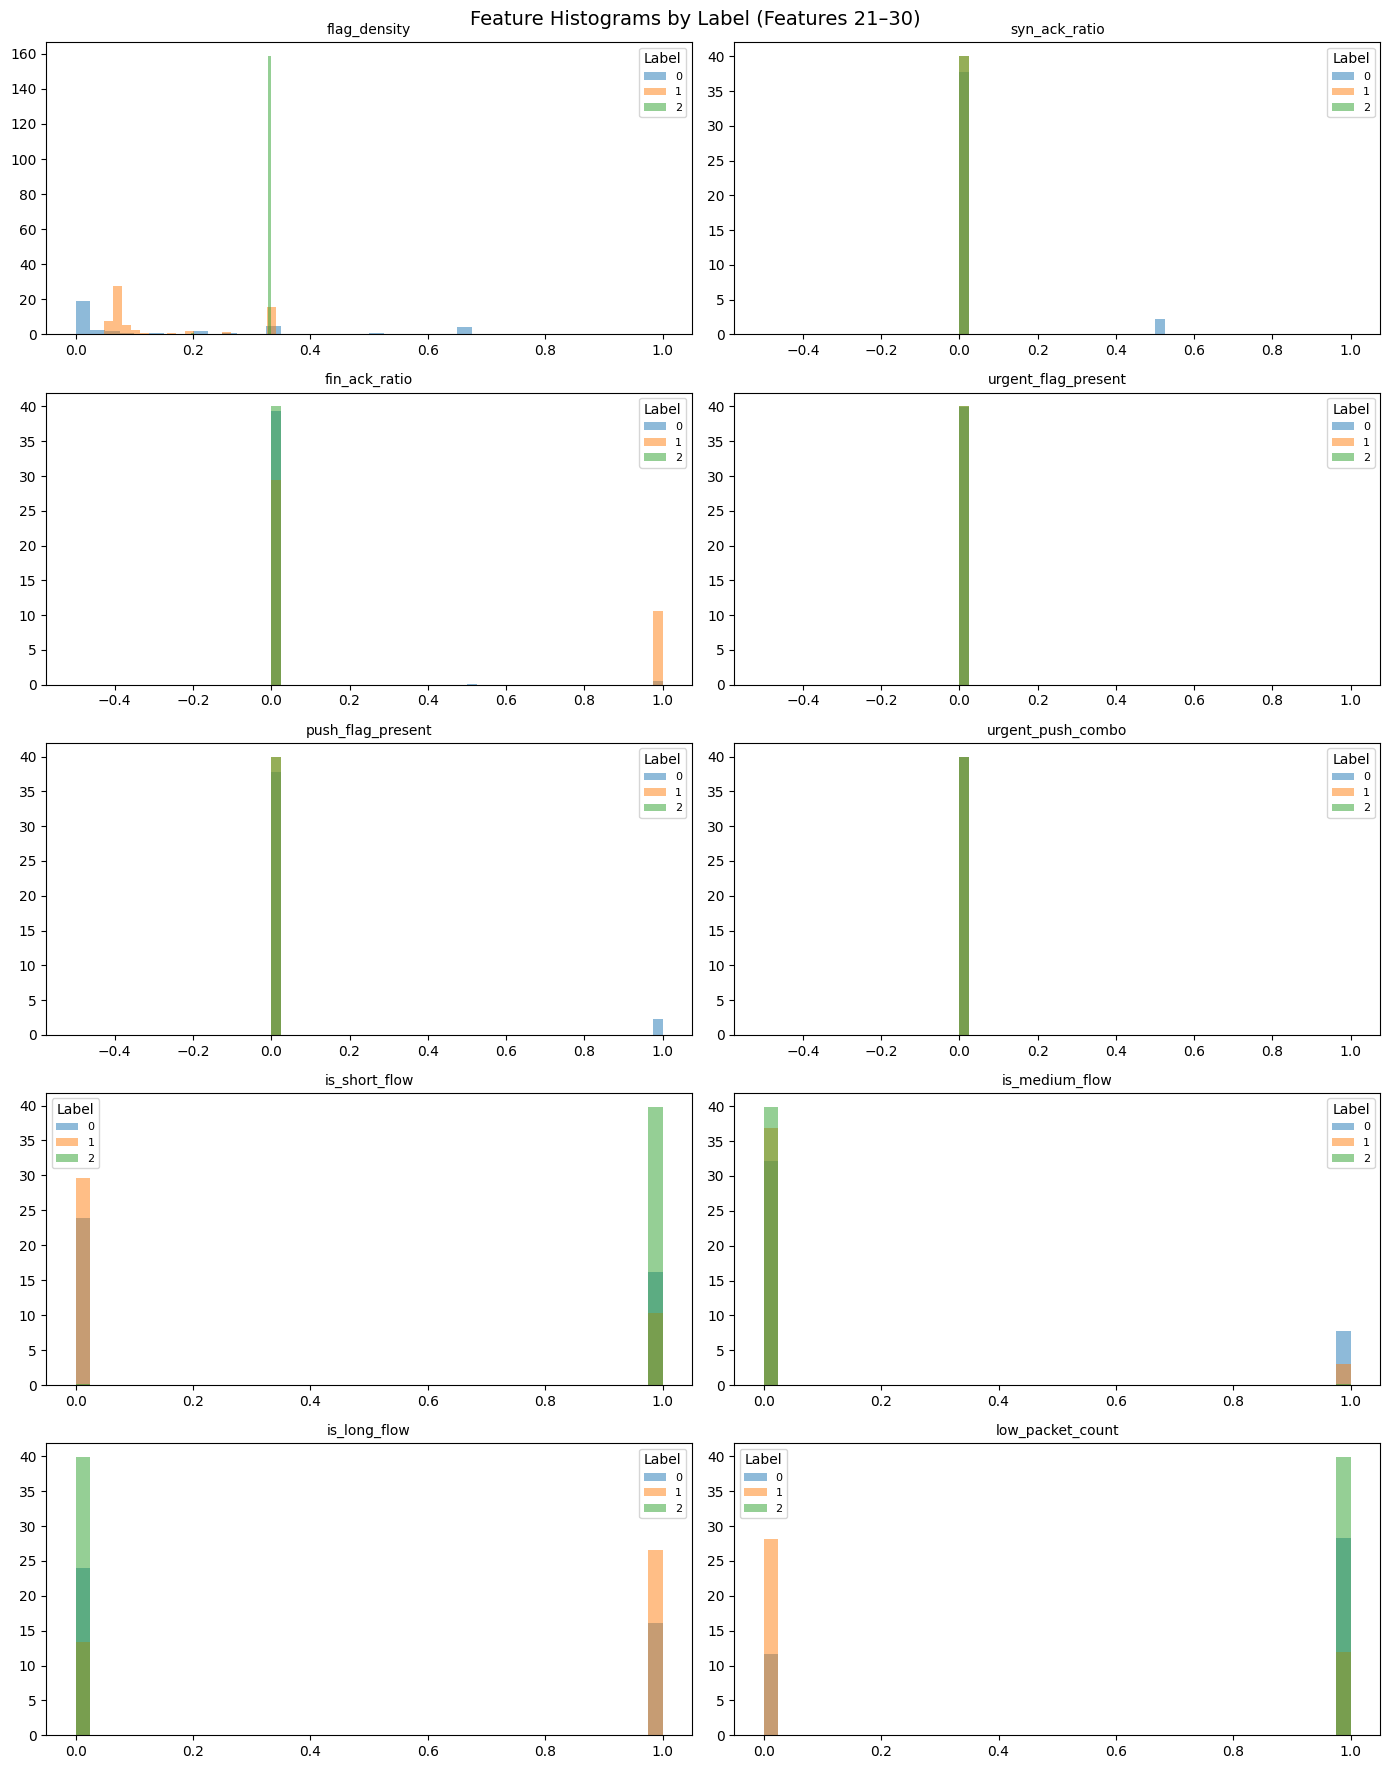

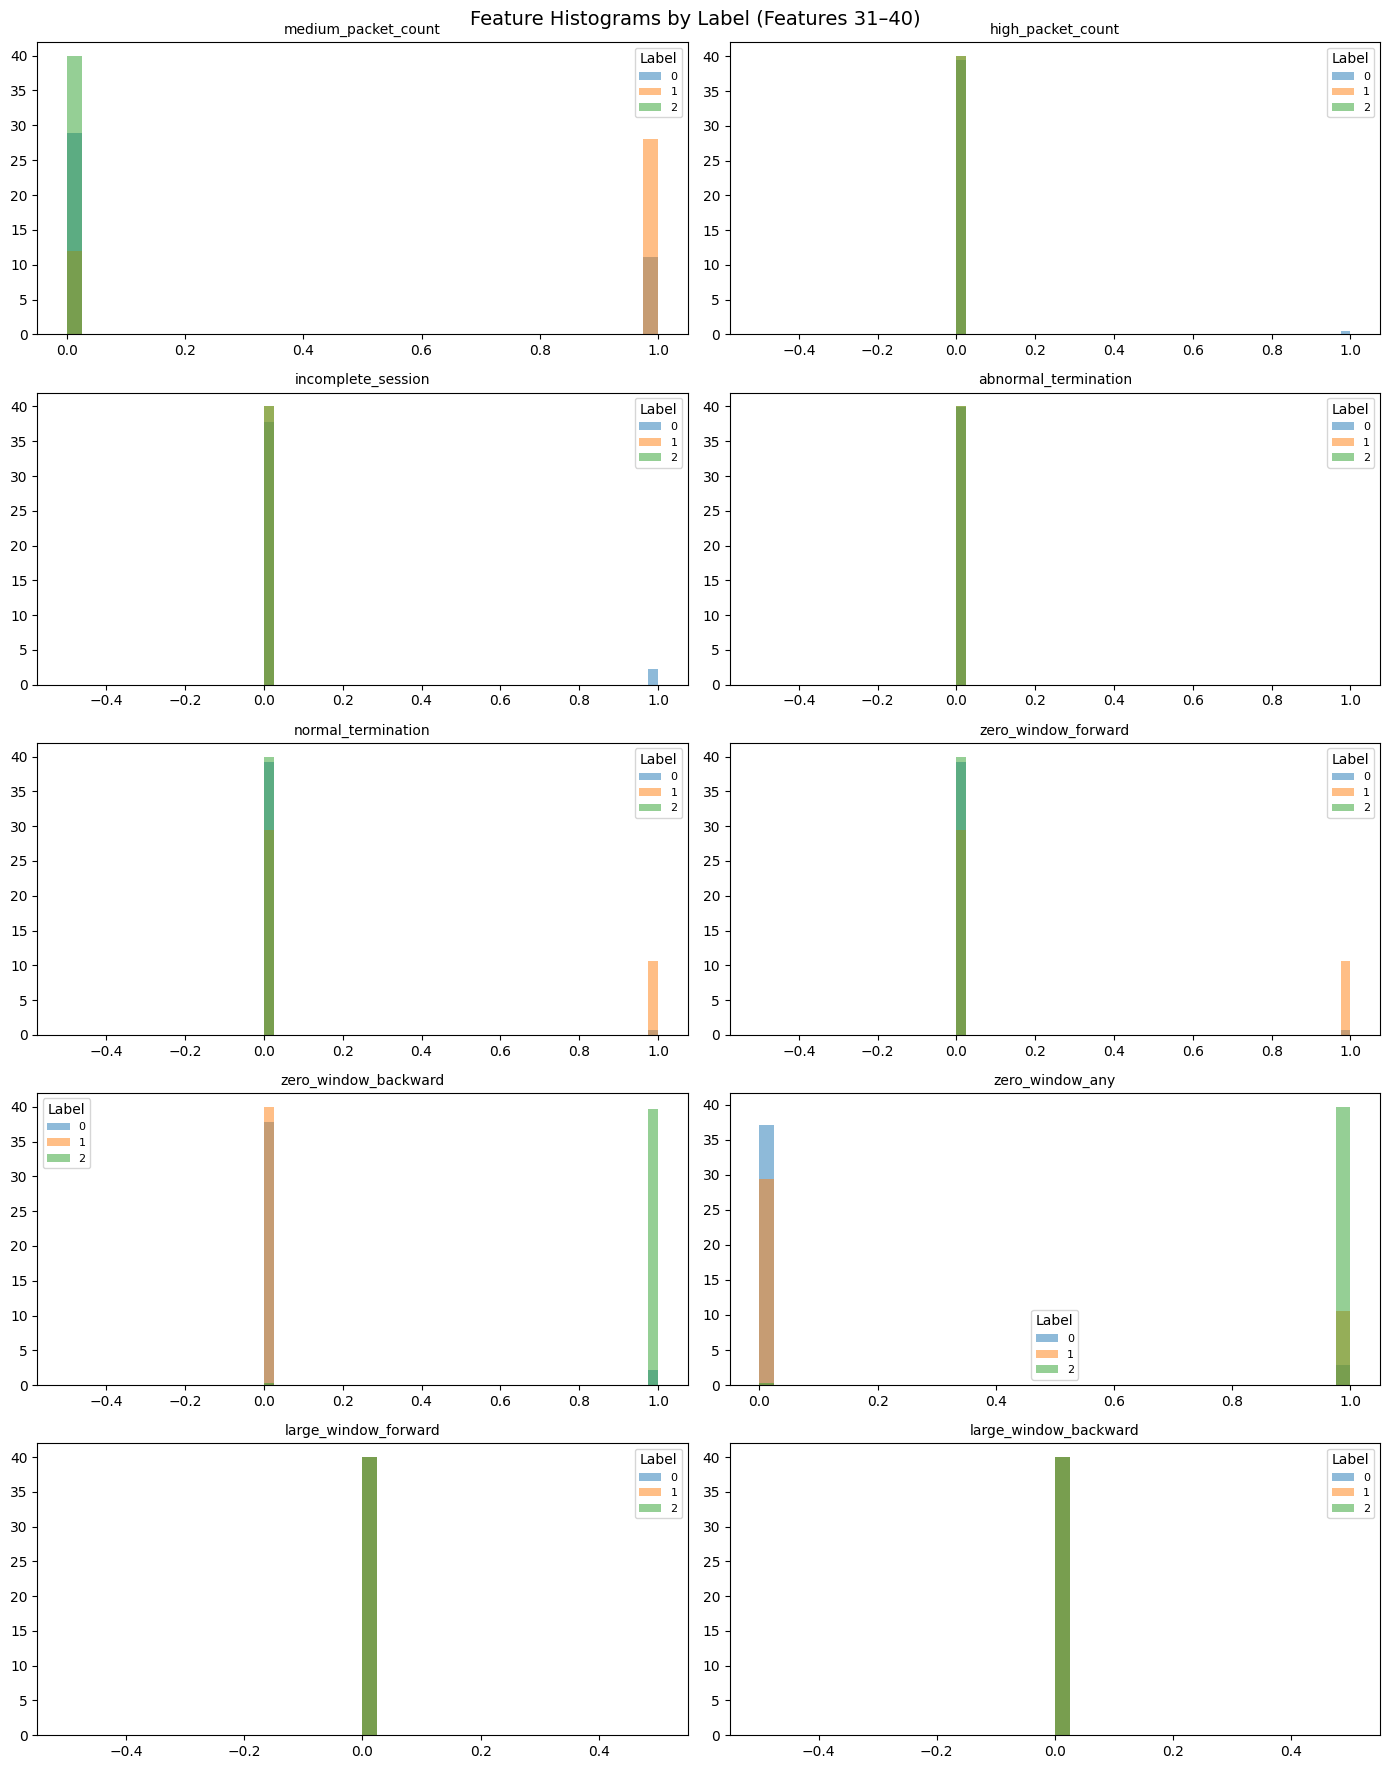

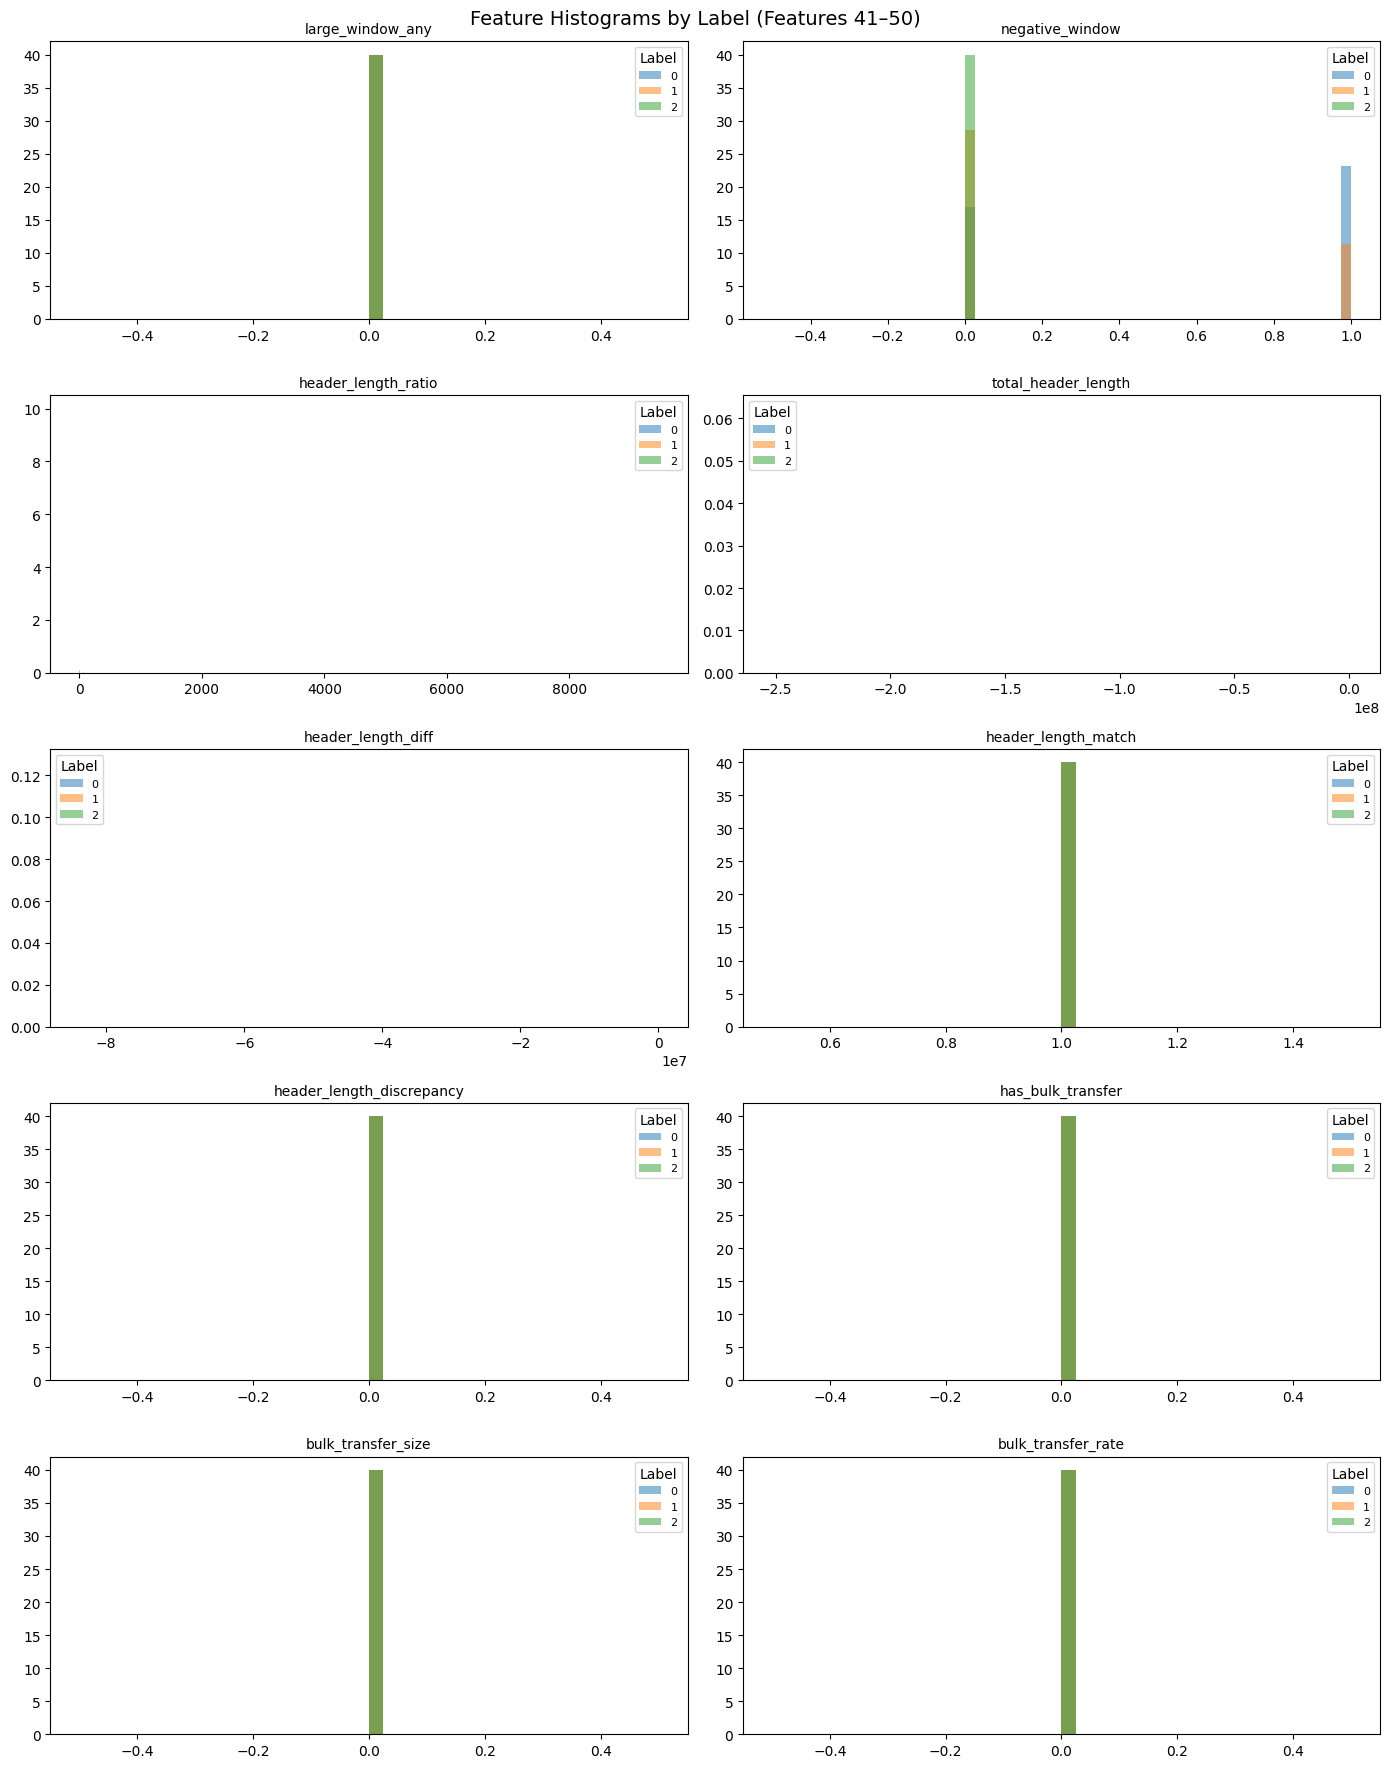

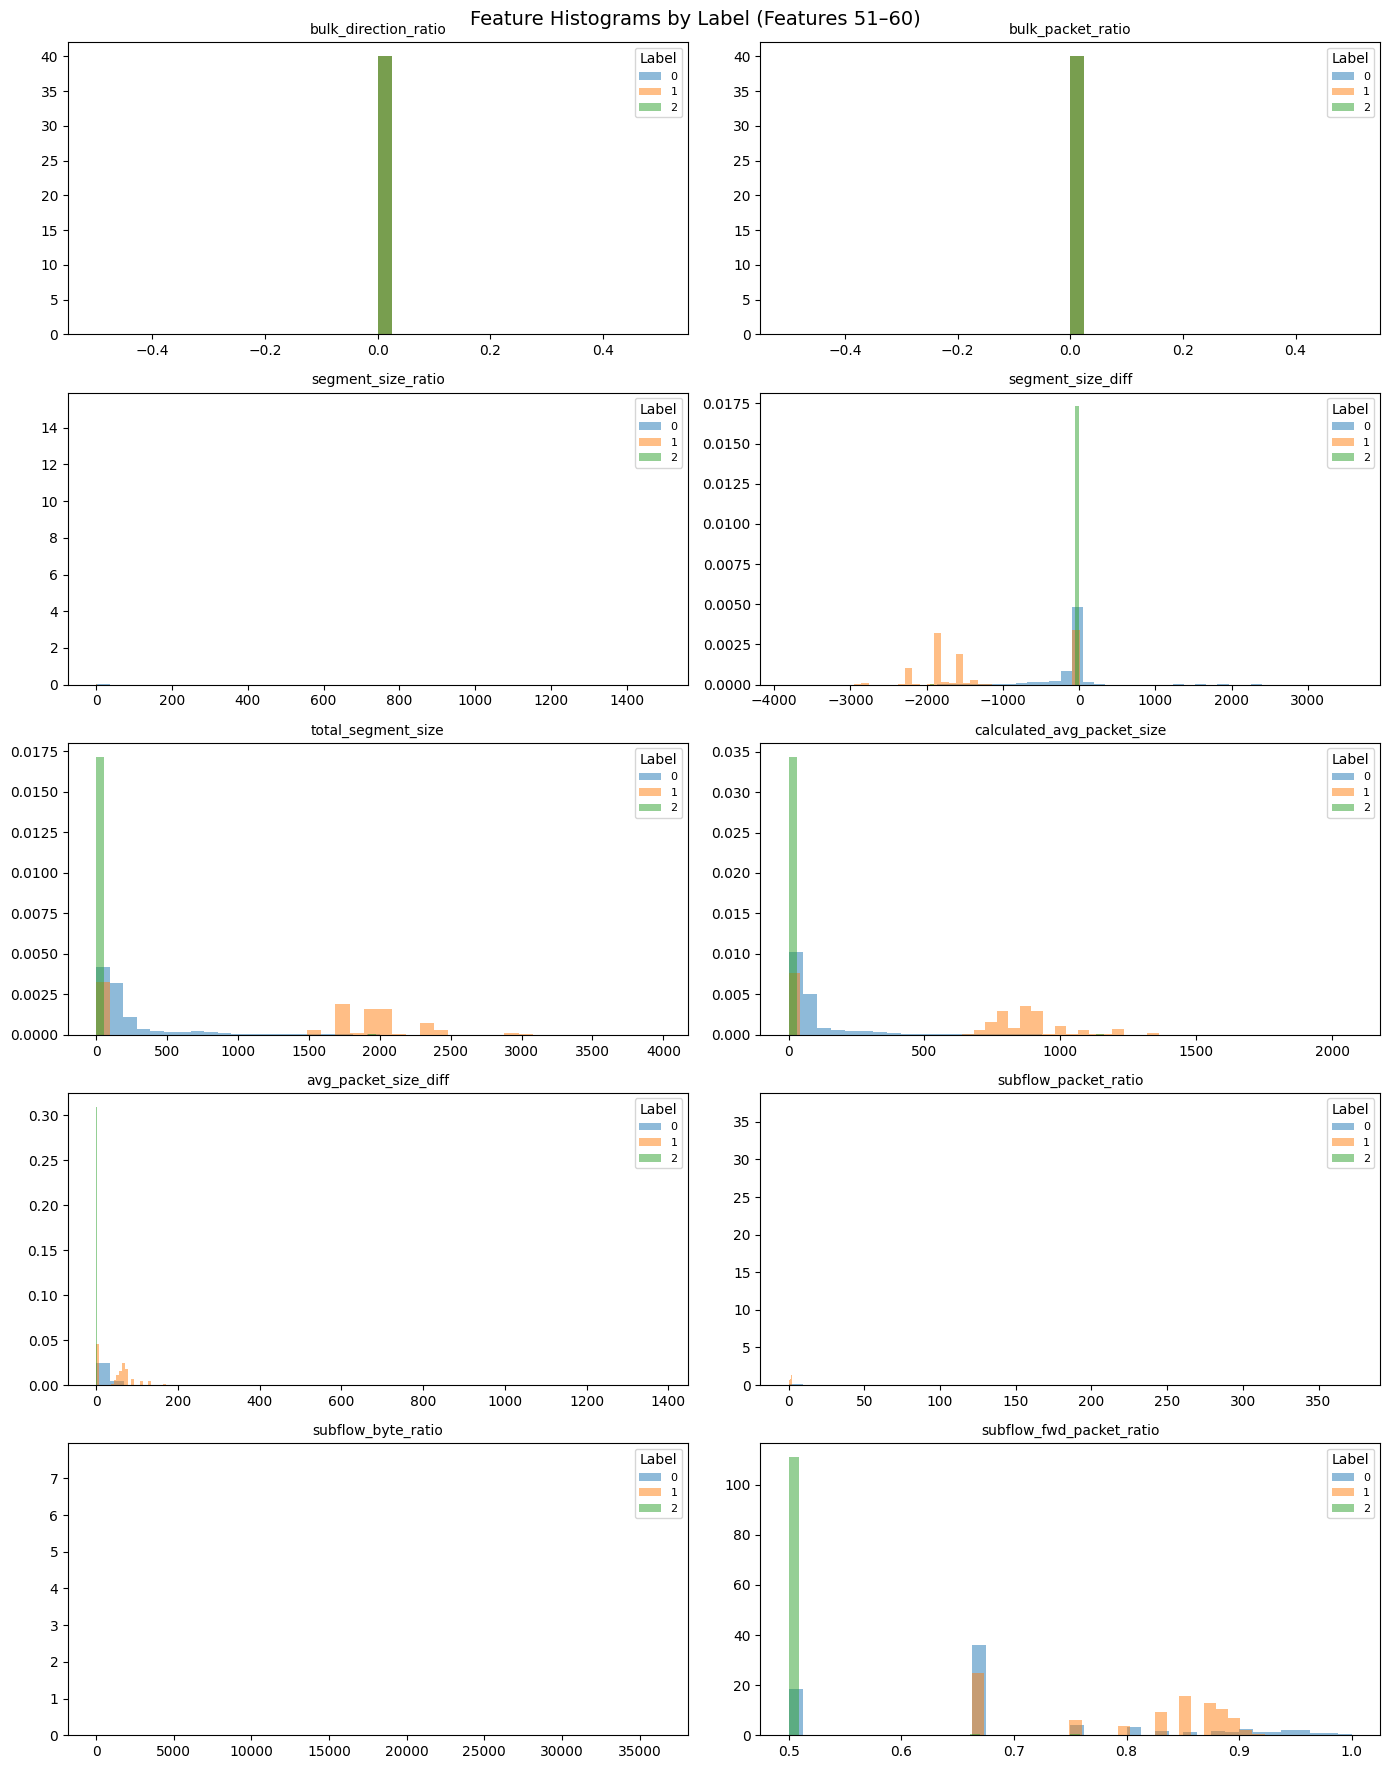

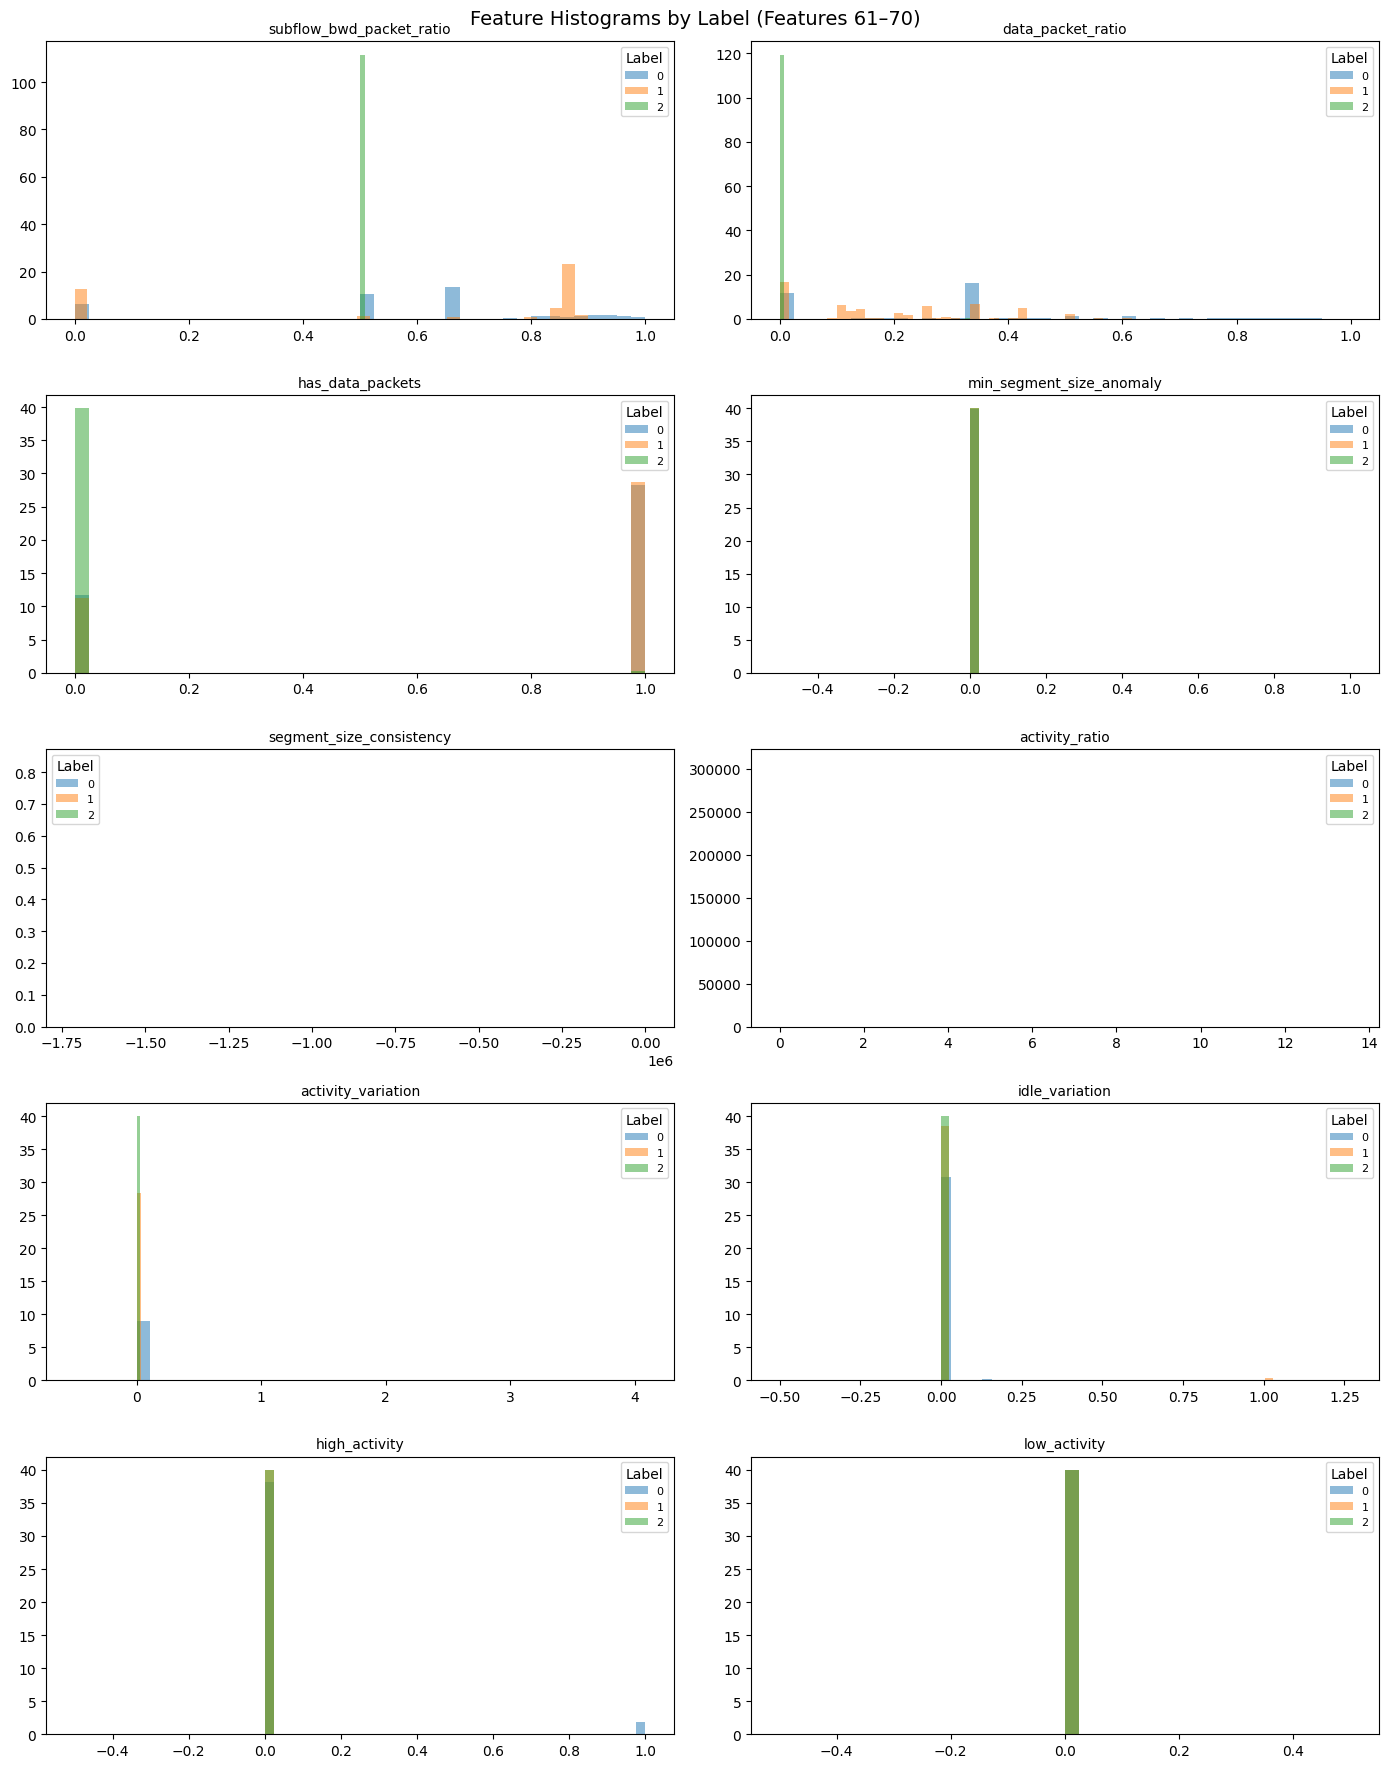

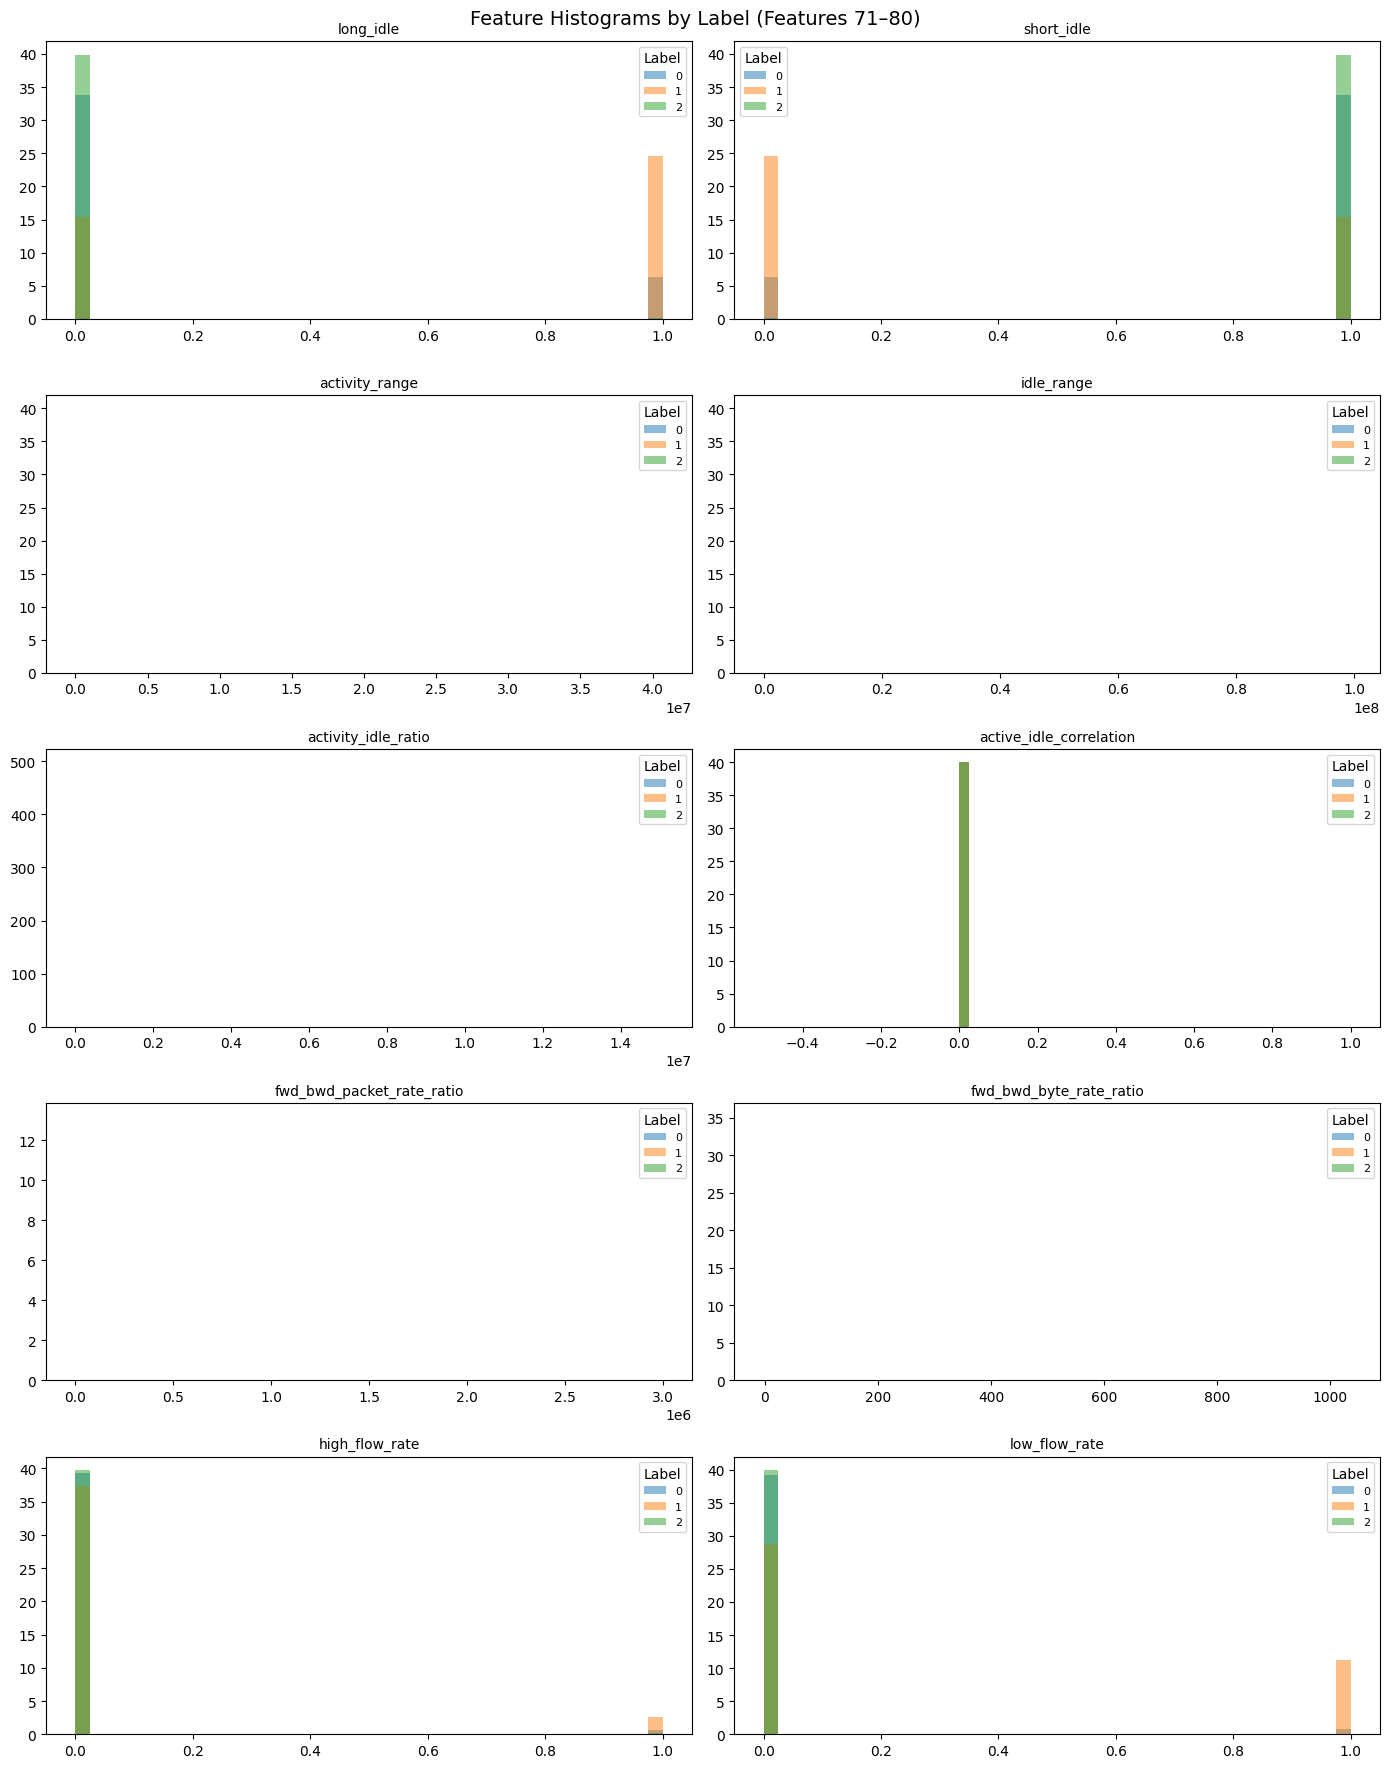

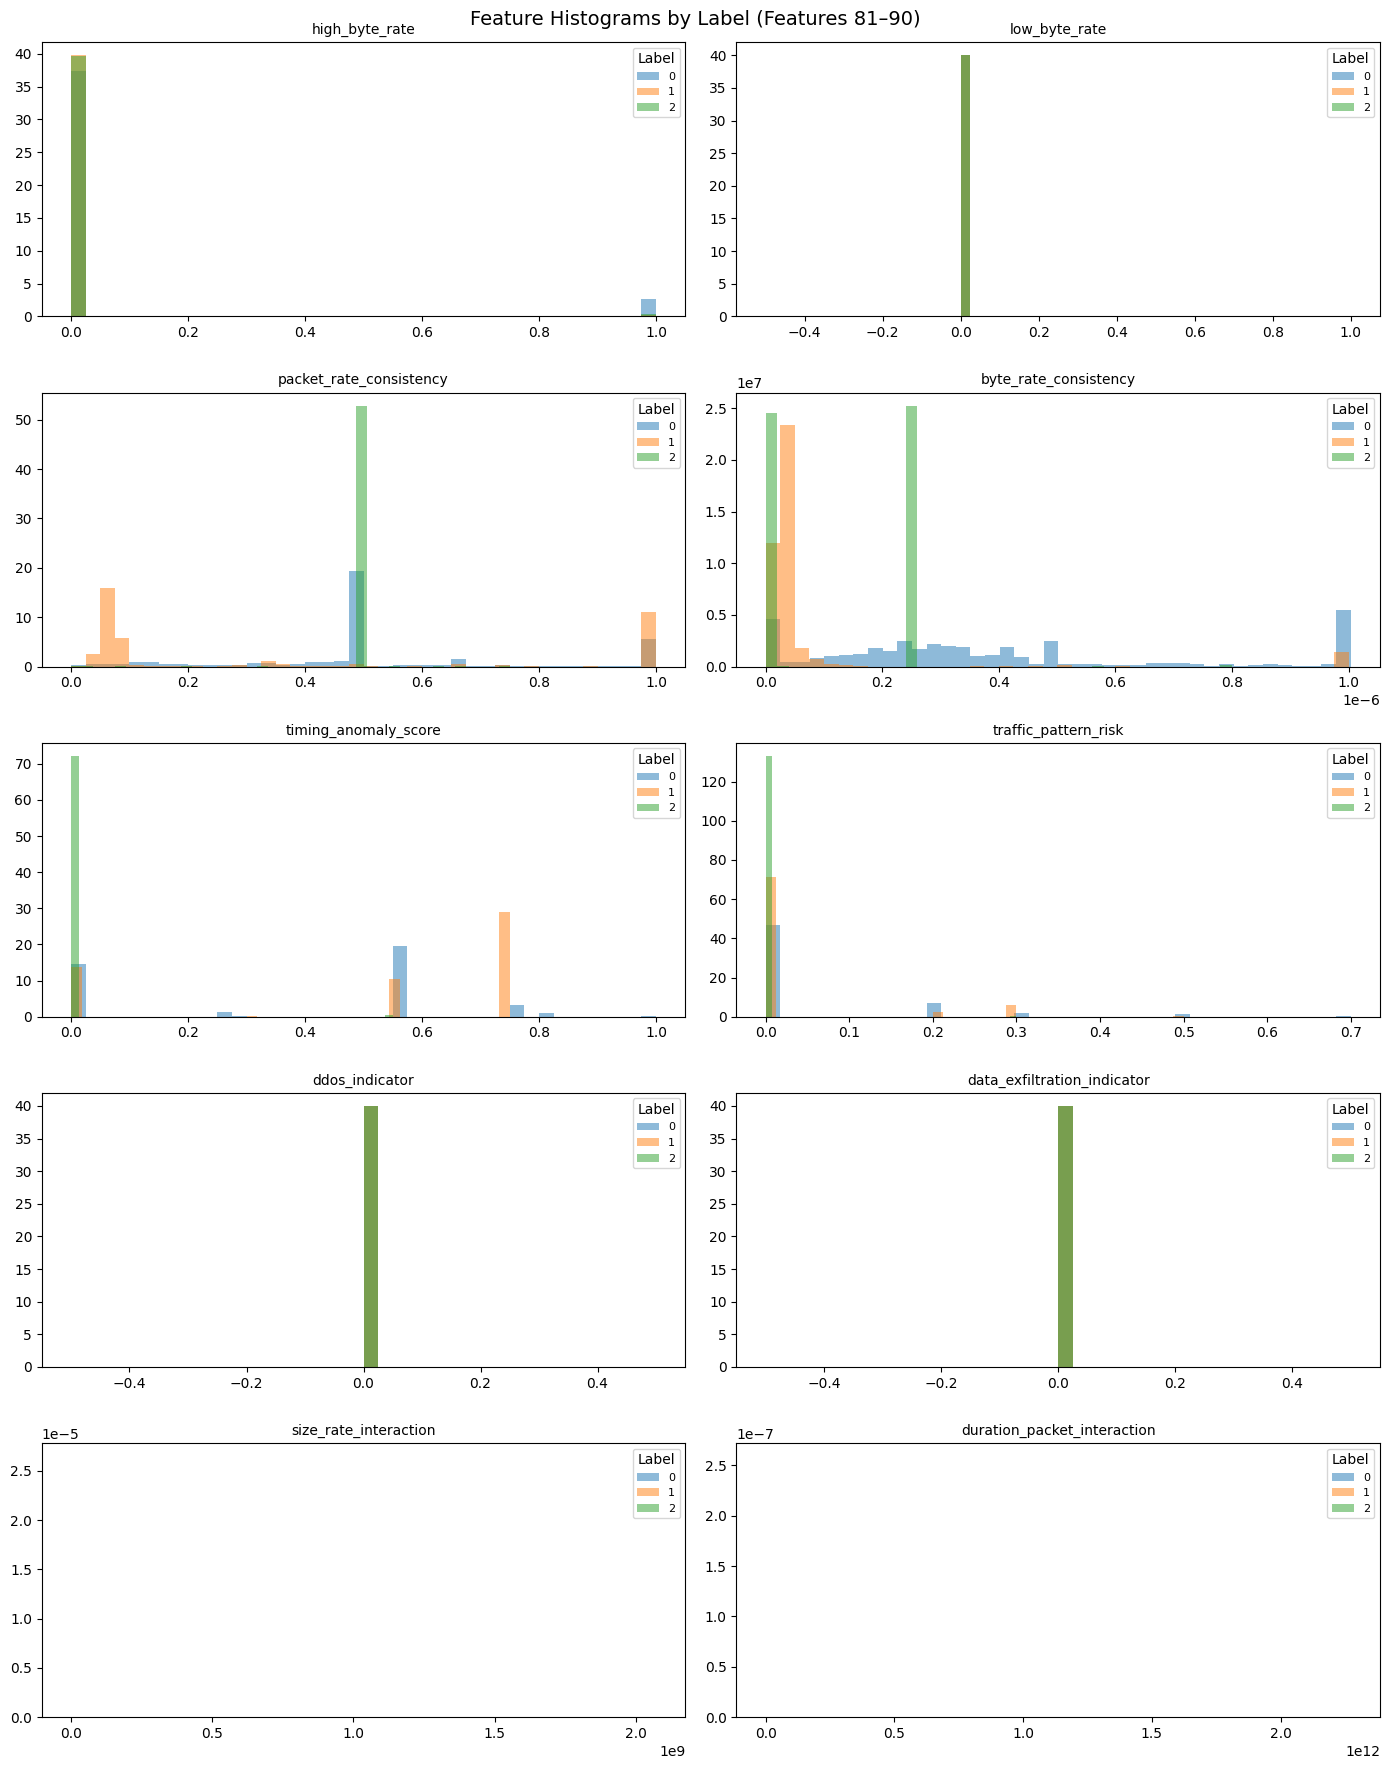

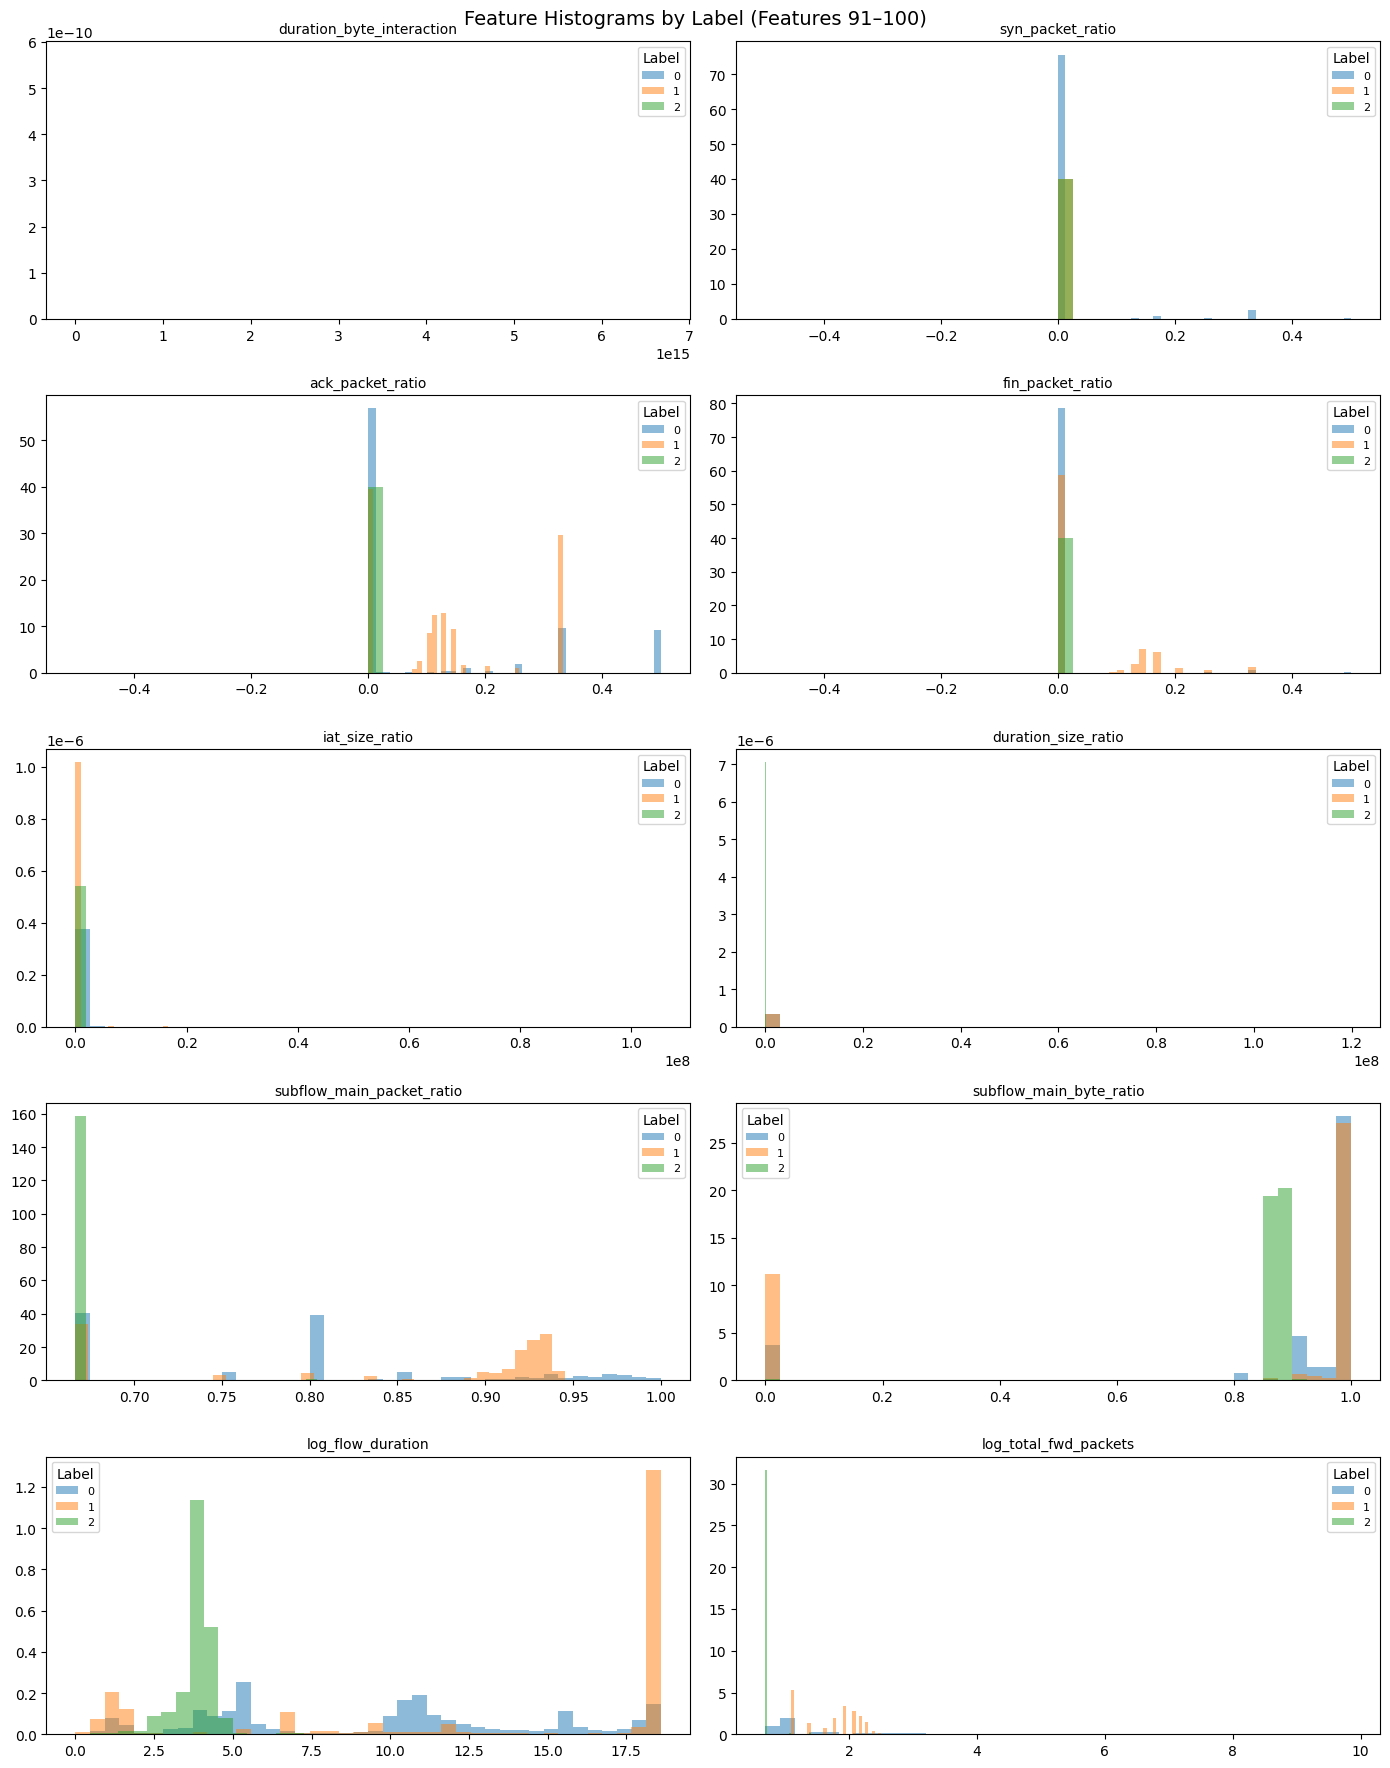

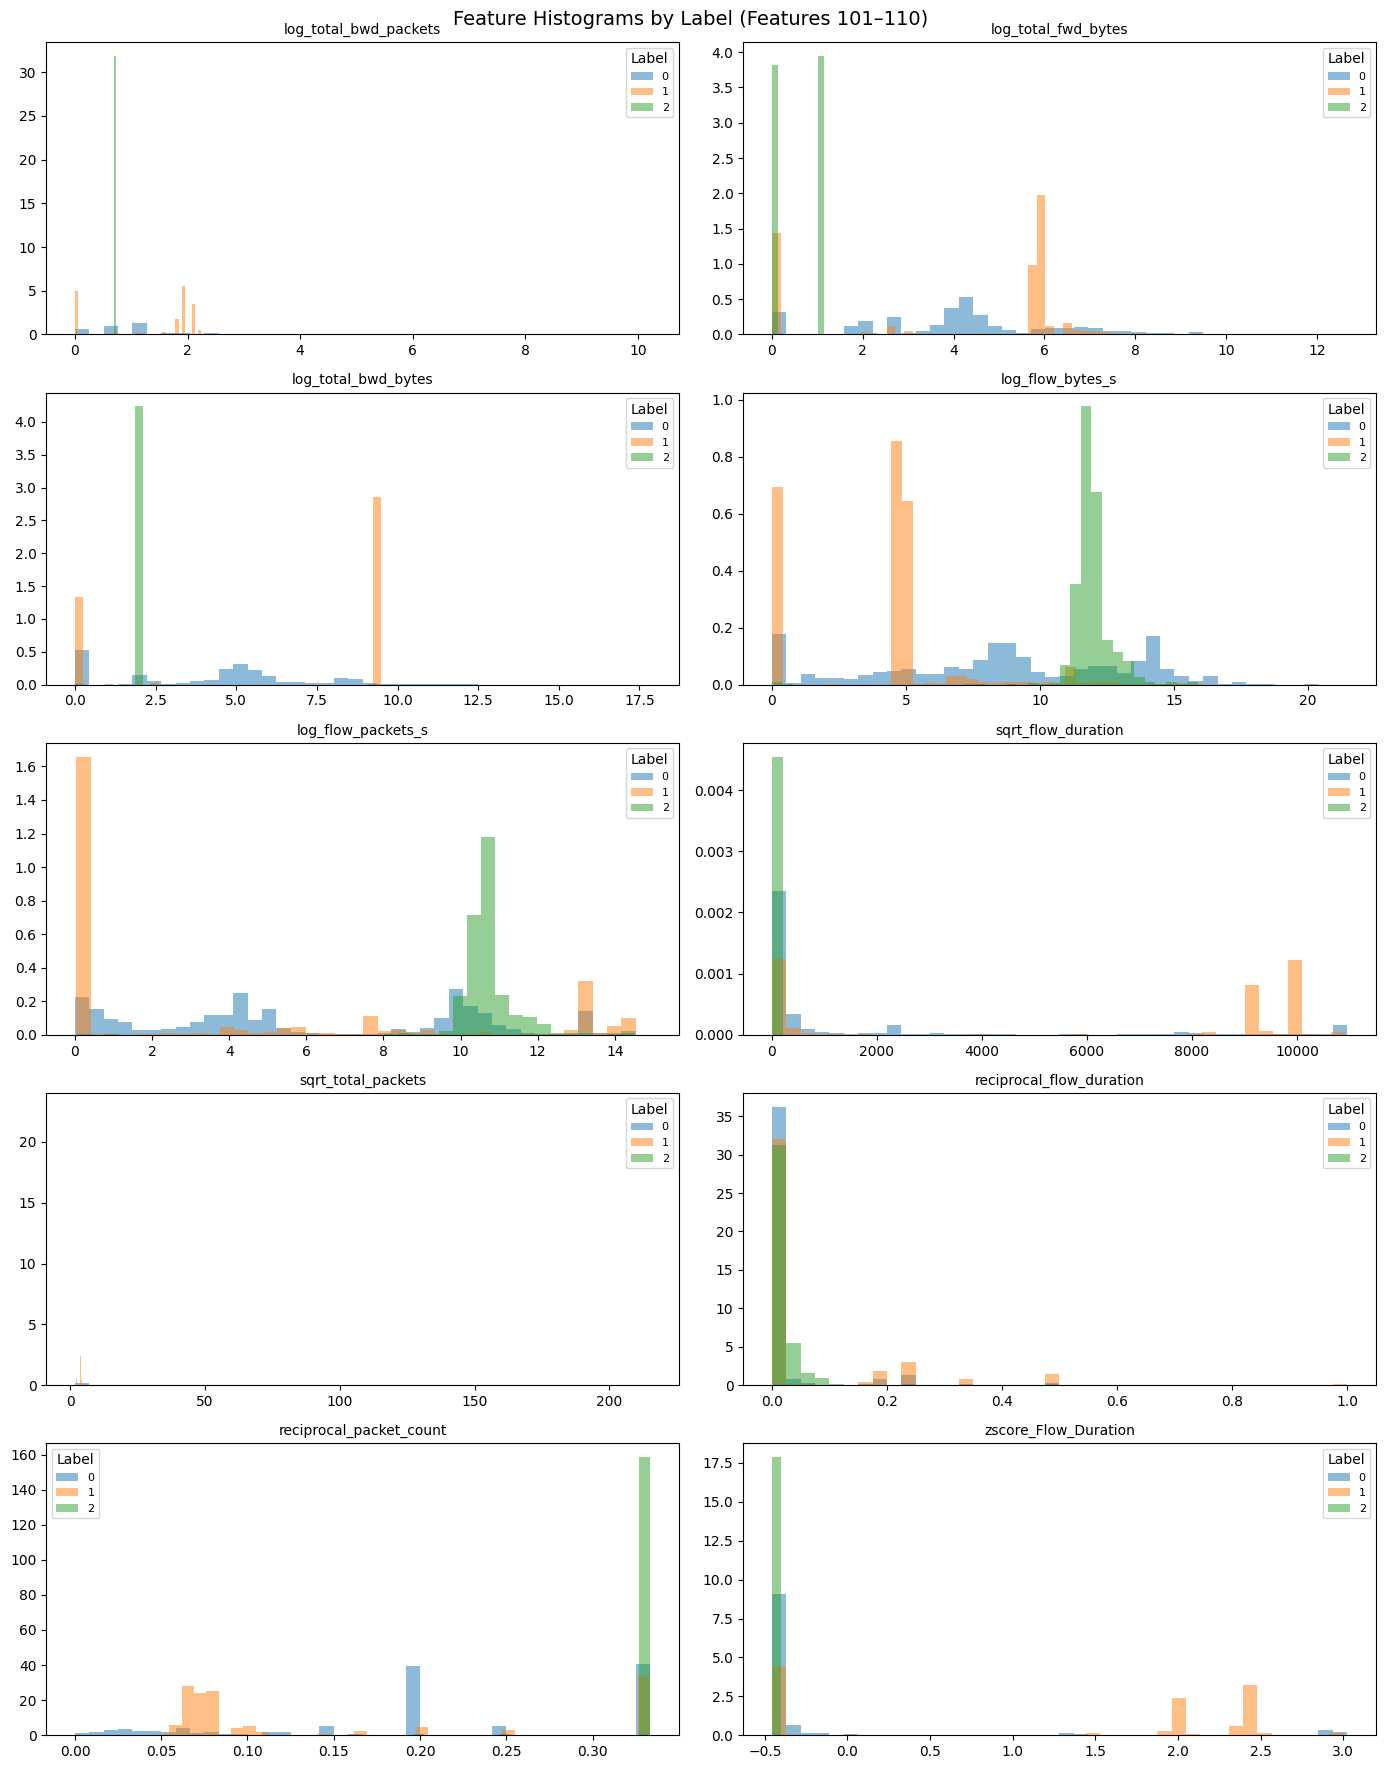

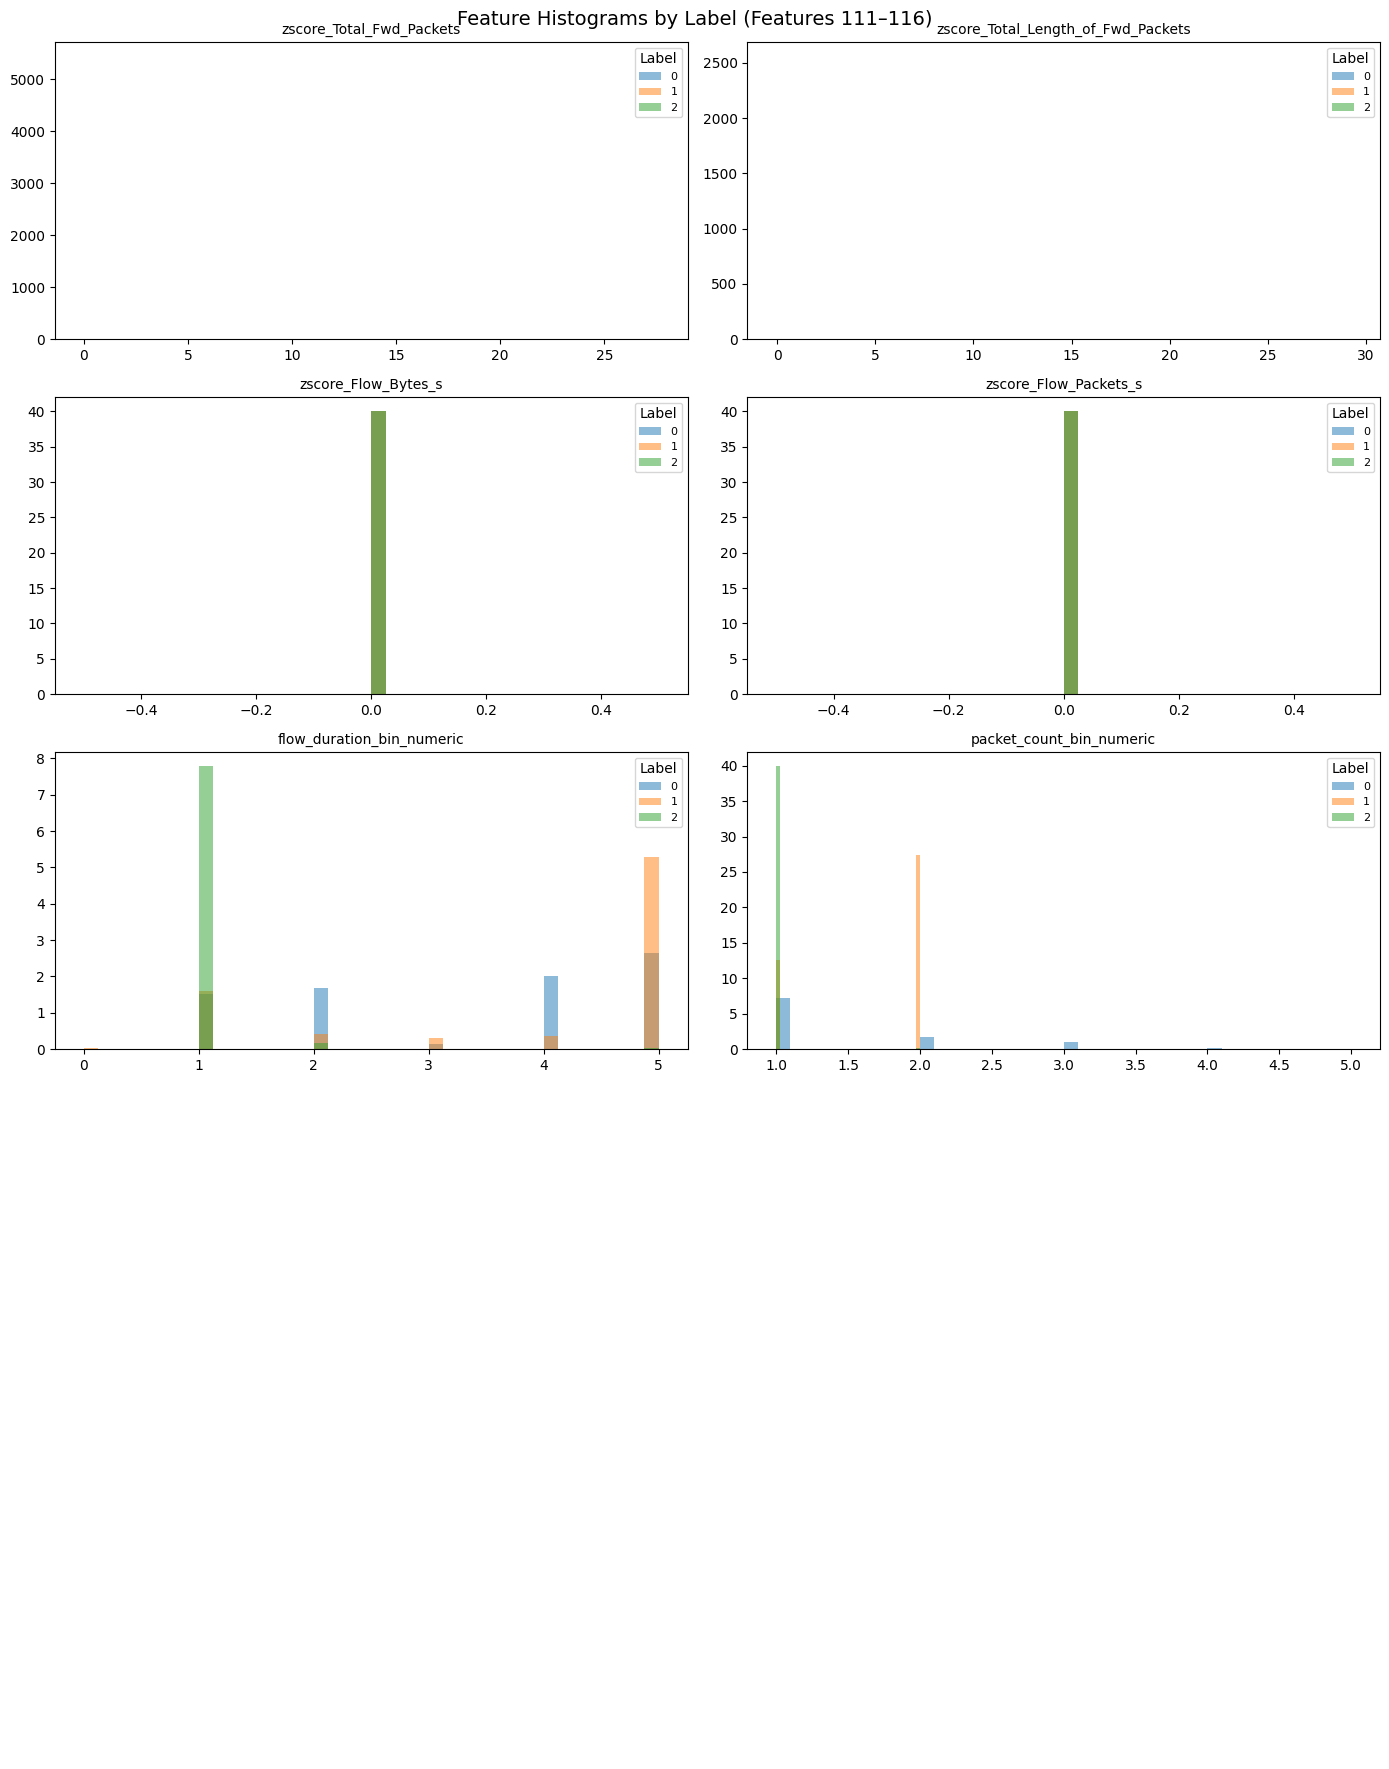

In [10]:
label_col = "Label_multi"
features_per_fig = 10
sample_n = 50000
bins = 40

dfp = df.replace([np.inf, -np.inf], np.nan).dropna(subset=[label_col]).copy()
dfp[label_col] = dfp[label_col].astype(int)

num_cols = dfp.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in num_cols if c != label_col]

if sample_n is not None and len(dfp) > sample_n:
    dfp = dfp.sample(sample_n, random_state=42)

labels = sorted(dfp[label_col].unique().tolist())

for start in range(0, len(feature_cols), features_per_fig):
    batch = feature_cols[start:start + features_per_fig]

    fig, axes = plt.subplots(5, 2, figsize=(14, 18))
    axes = axes.flatten()

    for i, feat in enumerate(batch):
        ax = axes[i]
        for lab in labels:
            vals = dfp.loc[dfp[label_col] == lab, feat].dropna().values
            ax.hist(vals, bins=bins, alpha=0.5, density=True, label=str(lab))
        ax.set_title(feat, fontsize=10)
        ax.legend(title="Label", fontsize=8)

    for j in range(len(batch), len(axes)):
        axes[j].axis("off")

    fig.suptitle(f"Feature Histograms by Label (Features {start+1}–{start+len(batch)})", fontsize=14)
    plt.tight_layout()
    plt.show()
